In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# Load 5 years of FSI data (2019-2023)
# Each file contains the 12 indicators needed for regression
years = [2019, 2020, 2021, 2022, 2023]
dfs = []

for year in years:
    file_path = f'data/fsi-{year}.xlsx'
    df = pd.read_excel(file_path)
    dfs.append(df)
    print(f"Loaded {year}: {df.shape[0]} rows")

# Combine all years into one dataset
fsi_data = pd.concat(dfs, ignore_index=True)
print(f"\nCombined dataset shape: {fsi_data.shape}")
print(f"\nColumns: {fsi_data.columns.tolist()}")

Loaded 2019: 178 rows
Loaded 2020: 178 rows
Loaded 2021: 179 rows
Loaded 2022: 179 rows
Loaded 2023: 179 rows

Combined dataset shape: (893, 17)

Columns: ['Country', 'Year', 'Rank', 'Total', 'C1: Security Apparatus', 'C2: Factionalized Elites', 'C3: Group Grievance', 'E1: Economy', 'E2: Economic Inequality', 'E3: Human Flight and Brain Drain', 'P1: State Legitimacy', 'P2: Public Services', 'P3: Human Rights', 'S1: Demographic Pressures', 'S2: Refugees and IDPs', 'X1: External Intervention', 'Change from Previous Year']


In [9]:
# Target variable: Total Fragility Score
target = 'Total'

# 12 sub-indicators as features (based on Excel column names)
feature_columns = [
    'C1: Security Apparatus',
    'C2: Factionalized Elites',
    'C3: Group Grievance',
    'E1: Economy',
    'E2: Economic Inequality',
    'E3: Human Flight and Brain Drain',
    'P1: State Legitimacy',
    'P2: Public Services',
    'P3: Human Rights',
    'S1: Demographic Pressures',
    'S2: Refugees and IDPs',
    'X1: External Intervention'
]

# Create feature matrix and target vector
X = fsi_data[feature_columns].copy()
y = fsi_data[target]

# Check for missing values
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nMissing values in features:\n{X.isnull().sum()}")
print(f"\nTarget statistics:\n{y.describe()}")

Features shape: (893, 12)
Target shape: (893,)

Missing values in features:
C1: Security Apparatus              0
C2: Factionalized Elites            0
C3: Group Grievance                 0
E1: Economy                         0
E2: Economic Inequality             0
E3: Human Flight and Brain Drain    0
P1: State Legitimacy                0
P2: Public Services                 0
P3: Human Rights                    0
S1: Demographic Pressures           0
S2: Refugees and IDPs               0
X1: External Intervention           0
dtype: int64

Target statistics:
count    893.000000
mean      66.400283
std       23.860294
min       14.500000
25%       49.868594
50%       69.800000
75%       83.300000
max      113.500000
Name: Total, dtype: float64


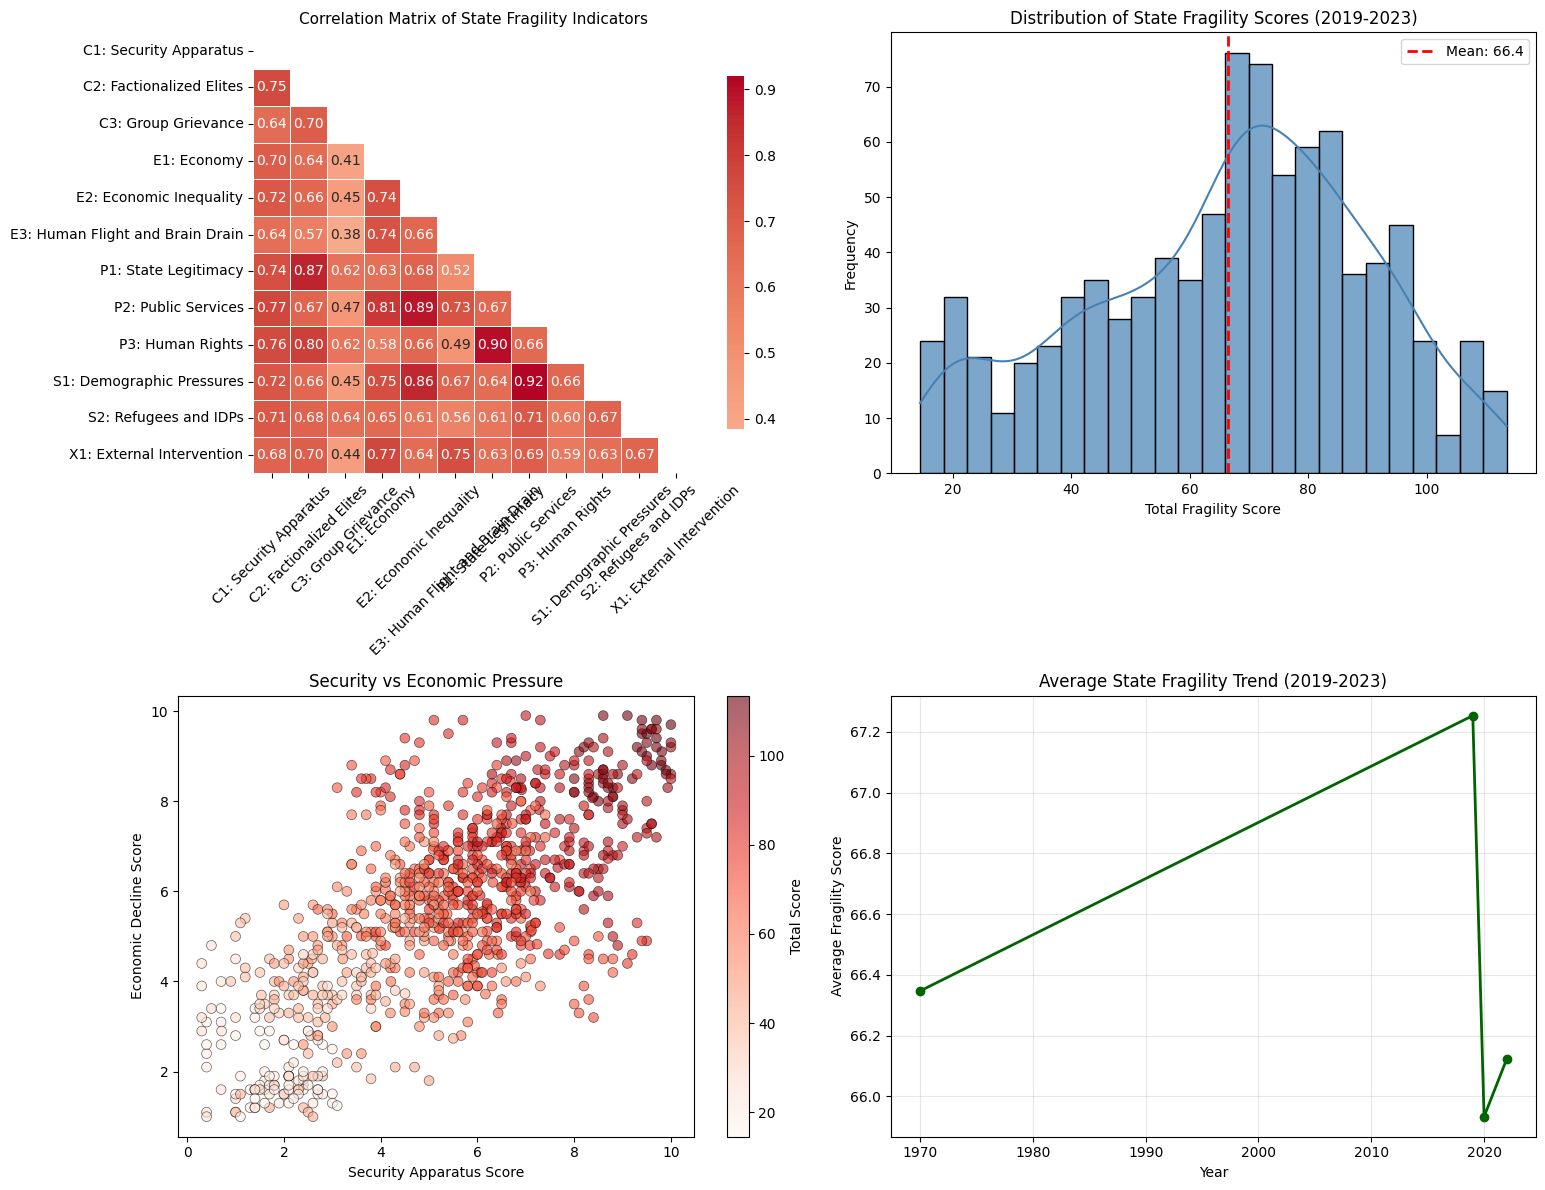

Saved: data_visualizations.png


In [11]:
# Create visualizations for data exploration
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Extract year from Timestamp objects
fsi_data['Year'] = pd.to_datetime(fsi_data['Year']).dt.year

# 1. Correlation heatmap of features
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', ax=axes[0,0],
            cbar_kws={"shrink": 0.8})
axes[0,0].set_title('Correlation Matrix of State Fragility Indicators', fontsize=11)
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Distribution of target variable
sns.histplot(y, bins=25, kde=True, color='steelblue', alpha=0.7, ax=axes[0,1])
axes[0,1].axvline(y.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {y.mean():.1f}')
axes[0,1].set_xlabel('Total Fragility Score')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of State Fragility Scores (2019-2023)')
axes[0,1].legend()

# 3. Security vs Economic Decline colored by fragility
scatter = axes[1,0].scatter(X['C1: Security Apparatus'], X['E1: Economy'], 
                           c=y, cmap='Reds', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[1,0].set_xlabel('Security Apparatus Score')
axes[1,0].set_ylabel('Economic Decline Score')
axes[1,0].set_title('Security vs Economic Pressure')
plt.colorbar(scatter, ax=axes[1,0], label='Total Score')

# 4. Average fragility by year
yearly_avg = fsi_data.groupby('Year')[target].mean()
axes[1,1].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, 
               markersize=6, color='darkgreen')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Average Fragility Score')
axes[1,1].set_title('Average State Fragility Trend (2019-2023)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: data_visualizations.png")

In [12]:
# Analyze feature importance
feature_importance = X.corrwith(y).abs().sort_values(ascending=False)
print("Feature correlation with fragility score:")
print(feature_importance)

# South Sudan case study
south_sudan = fsi_data[fsi_data['Country'] == 'South Sudan']
if not south_sudan.empty:
    print("\nSouth Sudan data (most recent year):")
    print(south_sudan[['Year', 'Total'] + feature_columns].tail(1))

Feature correlation with fragility score:
P2: Public Services                 0.896892
C1: Security Apparatus              0.883067
C2: Factionalized Elites            0.874739
S1: Demographic Pressures           0.863406
P1: State Legitimacy                0.860171
E2: Economic Inequality             0.854310
P3: Human Rights                    0.840374
E1: Economy                         0.837307
X1: External Intervention           0.819808
S2: Refugees and IDPs               0.811360
E3: Human Flight and Brain Drain    0.762950
C3: Group Grievance                 0.684803
dtype: float64

South Sudan data (most recent year):
     Year  Total  C1: Security Apparatus  C2: Factionalized Elites  \
716  1970  108.5                     9.9                       9.2   

     C3: Group Grievance  E1: Economy  E2: Economic Inequality  \
716                  8.6          8.6                      8.6   

     E3: Human Flight and Brain Drain  P1: State Legitimacy  \
716                         

In [13]:
# Standardize features for linear regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns)

# Split data
y_binned = pd.cut(y, bins=4, labels=['low', 'medium', 'high', 'critical'])
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Training: 714 samples
Test: 179 samples


In [14]:
# Initialize three models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=12, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=15, 
                                          min_samples_split=5, random_state=42, n_jobs=-1)
}

results = {}

print("Training models...")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    
    results[name] = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'r2_score': r2,
        'model': model,
        'predictions': y_test_pred
    }
    
    print(f"{name}:")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Test MSE:  {test_mse:.4f}")
    print(f"  R2:        {r2:.4f}")
    print()

# Best model
best_model_name = min(results, key=lambda x: results[x]['test_mse'])
best_model = results[best_model_name]['model']
best_r2 = results[best_model_name]['r2_score']

print(f"Best: {best_model_name} (Test MSE: {results[best_model_name]['test_mse']:.4f})")

Training models...
------------------------------------------------------------
Linear Regression:
  Train MSE: 0.0008
  Test MSE:  0.0005
  R2:        1.0000

Decision Tree:
  Train MSE: 2.3748
  Test MSE:  10.8825
  R2:        0.9807

Random Forest:
  Train MSE: 0.7166
  Test MSE:  2.8910
  R2:        0.9949

Best: Linear Regression (Test MSE: 0.0005)


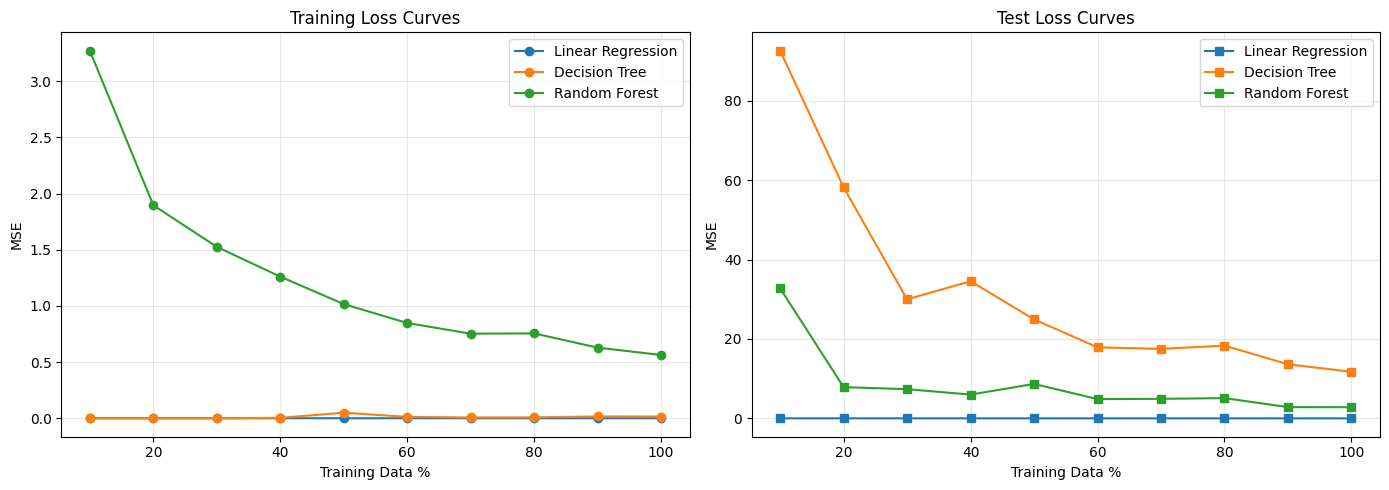

Saved: loss_curves.png


In [15]:
# Generate learning curves
train_sizes = np.linspace(0.1, 1.0, 10)
train_losses = {name: [] for name in models.keys()}
test_losses = {name: [] for name in models.keys()}

for size in train_sizes:
    n_samples = int(len(X_train) * size)
    X_subset = X_train.iloc[:n_samples]
    y_subset = y_train.iloc[:n_samples]
    
    temp_models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(max_depth=12, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
    }
    
    for name, temp_model in temp_models.items():
        temp_model.fit(X_subset, y_subset)
        train_losses[name].append(mean_squared_error(y_subset, temp_model.predict(X_subset)))
        test_losses[name].append(mean_squared_error(y_test, temp_model.predict(X_test)))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in models.keys():
    ax1.plot(train_sizes * 100, train_losses[name], marker='o', label=name)
ax1.set_xlabel('Training Data %')
ax1.set_ylabel('MSE')
ax1.set_title('Training Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

for name in models.keys():
    ax2.plot(train_sizes * 100, test_losses[name], marker='s', label=name)
ax2.set_xlabel('Training Data %')
ax2.set_ylabel('MSE')
ax2.set_title('Test Loss Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")

In [17]:
# Save best model
artifacts = {
    'model': best_model,
    'scaler': scaler,
    'features': feature_columns,
    'model_type': best_model_name,
    'metrics': {
        'mse': results[best_model_name]['test_mse'],
        'r2': best_r2
    }
}

joblib.dump(artifacts, 'best_fragility_model.pkl')
print("Saved: best_fragility_model.pkl")

Saved: best_fragility_model.pkl


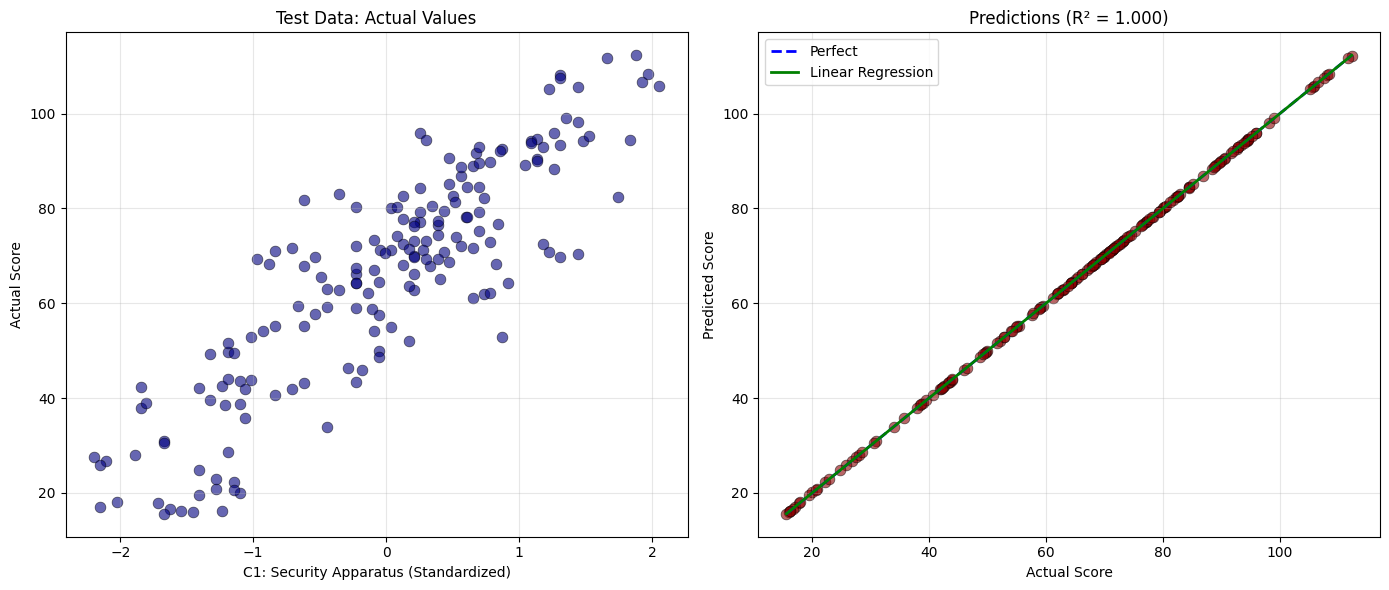

Saved: regression_fit.png


In [16]:
# Scatter plot of predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before
top_feature = feature_columns[0]
ax1.scatter(X_test[top_feature], y_test, alpha=0.6, color='navy', s=60, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'{top_feature} (Standardized)')
ax1.set_ylabel('Actual Score')
ax1.set_title('Test Data: Actual Values')
ax1.grid(True, alpha=0.3)

# After
predictions = results[best_model_name]['predictions']
ax2.scatter(y_test, predictions, alpha=0.6, color='darkred', s=60, edgecolors='black', linewidth=0.5)

min_val, max_val = y_test.min(), y_test.max()
ax2.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=2, label='Perfect')

z = np.polyfit(y_test, predictions, 1)
p = np.poly1d(z)
ax2.plot(sorted(y_test), p(sorted(y_test)), "g-", linewidth=2, label=f'{best_model_name}')

ax2.set_xlabel('Actual Score')
ax2.set_ylabel('Predicted Score')
ax2.set_title(f'Predictions (R² = {best_r2:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_fit.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: regression_fit.png")

In [18]:
def predict_fragility(input_data):
    """
    Predict state fragility for a single observation.
    input_data: dict with all 12 indicator values
    """
    artifacts = joblib.load('best_fragility_model.pkl')
    model = artifacts['model']
    scaler = artifacts['scaler']
    features = artifacts['features']
    
    input_df = pd.DataFrame([input_data])[features]
    input_scaled = scaler.transform(input_df)
    score = model.predict(input_scaled)[0]
    
    if score < 40:
        risk = "Sustainable"
    elif score < 60:
        risk = "Stable"
    elif score < 80:
        risk = "Warning"
    elif score < 100:
        risk = "Alert"
    else:
        risk = "Critical"
    
    return {'score': round(score, 2), 'risk': risk}

# Test on one row
sample = X.iloc[X_test.index[0]].to_dict()
actual = y_test.iloc[0]
result = predict_fragility(sample)

print("Sample prediction:")
print(f"Input: {sample}")
print(f"Actual: {actual:.2f}")
print(f"Predicted: {result['score']} ({result['risk']})")

Sample prediction:
Input: {'C1: Security Apparatus': 8.6, 'C2: Factionalized Elites': 9.5, 'C3: Group Grievance': 8.4, 'E1: Economy': 8.7, 'E2: Economic Inequality': 8.8, 'E3: Human Flight and Brain Drain': 8.0, 'P1: State Legitimacy': 9.4, 'P2: Public Services': 9.7, 'P3: Human Rights': 8.3, 'S1: Demographic Pressures': 9.6, 'S2: Refugees and IDPs': 9.1, 'X1: External Intervention': 7.6}
Actual: 105.70
Predicted: 105.7 (Critical)
